# Minimizers, gradient flows and gradient descent

*Introduction to Control and Machine Learning · Part II: Optimization and long-time control · Notebook 06*

> **Central question.** *When does a functional have a minimizer, and how do we compute it by following the gradient?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 70–85 min · DEEPER LOOK ≈ 15 min more |
| **Execution time** | a few seconds |
| **Exercises** | 6 exercises, ≈ 90–150 min |
| **Prerequisites** | multivariable calculus; eigenvalues of symmetric matrices. Helpful: [notebook 03](03_observability_duality_adjoints.ipynb) (the HUM functional and its Hessian) and [notebook 05](05_feedback_stabilization.ipynb) (energy identities) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 17–18, 21, 143–153, 172–174, 183–188 (see the Source map at the end) |
| **Notation** | `notation.md` §§1, 4, 10: step size $\eta$, gradient-flow time $\tau$, Lipschitz constant $L$ of the gradient with $M=L^2$, example E3. $\alpha$ is the strong-convexity constant of p. 183 |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE route §§1–8 (minimization → first-order conditions → existence → gradient flow → gradient descent → conditioning → back to HUM), the E3 laboratory (Figures 2–3), Exercises 1–2.
> *Deeper study:* the DEEPER LOOK sections §§9–12 (Fermat–Snell, linear programming and transport, the direct method in Hilbert spaces, long-time behaviour of gradient flows), Exercises 3–4.
> *Research-oriented:* the `ADVANCED` Exercises 5–7.

**Learning objectives.** After this notebook you should be able to

1. write first-order optimality conditions, with and without constraints, and use Lagrange multipliers;
2. prove the existence of a minimizer by the direct method, and say which hypothesis fails in a counterexample;
3. show that $J$ is a Lyapunov function of its gradient flow, and use this to prove convergence;
4. derive gradient descent as the explicit Euler scheme of the gradient flow, and prove its linear convergence for a range of step sizes;
5. explain, on the quadratic landscape E3, why the condition number controls the number of iterations and why a step larger than $2/\lambda_{\max}$ makes the method diverge;
6. formulate a transportation problem as a linear program.

## Where are we?
`CORE`

> **Recap.** Every control of Part I came from a **minimization principle**. In [notebook 03](03_observability_duality_adjoints.ipynb) the HUM functional $J(\varphi_T)=\tfrac12\int_0^T|B^*\varphi|^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$ was shown to be continuous, strictly convex and coercive, its minimizer gave the control of minimal $L^2$ norm, and its Hessian was the Gramian $\mathcal G_T$. In [notebook 04](04_structured_controls_bangbang_switching.ipynb) other functionals, $J_{bb}$ and $J_{sw}$, gave controls with structure. In [notebook 05](05_feedback_stabilization.ipynb) an **energy identity**, $\frac{d}{dt}|x|^2=-2|B^*x|^2$, gave the decay of a closed loop.

Part II studies these two ideas in their own right, in an order that will be repeated for learning: **minimization → existence → gradient flow → Lyapunov decay → Euler discretization → gradient descent.**

## 1. Minimization everywhere
`CORE`

> *"Nothing at all takes place in the universe in which some rule of the maximum or minimum does not appear."* L. Euler (p. 144)

The slides present a gallery of extremal problems (pp. 143–152): Dido's isoperimetric problem ($4\pi A\le L^2$, with equality only for the circle), geodesics as the shortest curves between two points, Fermat's principle in optics, Monge's optimal transport, and Plateau's minimal surfaces. All of them have the same abstract form (p. 153):
$$
J(u^*)=\min_{u\in U}J(u),
$$
where $U$ is a set of admissible objects (points, curves, controls, shapes, network parameters) and $J:U\to\mathbb R$ measures their cost.

Two questions organize this notebook.

- **Existence.** Is the minimum attained, or is it only an infimum? (§3)
- **Computation.** How do we find $u^*$? The answer of the slides is the gradient method $u_{k+1}=u_k-\rho\nabla J(u_k)$ (p. 153), which we write with the step size $\eta$ (`notation.md`). (§§4–6)

Before either, we recall what a minimizer must satisfy.

## 2. First-order conditions and Lagrange multipliers
`CORE`

**Without constraints.** If $J:\mathbb R^n\to\mathbb R$ is differentiable and $u^*$ is a minimizer, then $\nabla J(u^*)=0$. Otherwise $J(u^*-s\nabla J(u^*))=J(u^*)-s|\nabla J(u^*)|^2+o(s)<J(u^*)$ for small $s>0$. Points with $\nabla J=0$ are **critical points**. They include minimizers, maximizers and saddles.

**With an equality constraint (pp. 17–18).** Consider
$$
\min_{g(x)=c}f(x).
$$
Critical points are those for which
$$
\nabla f(x)=\lambda\,\nabla g(x)\qquad\text{for some real }\lambda .
$$
The reason is geometric. $\nabla g(x)$ is the normal to the level set $\{g=c\}$ on which the minimization occurs. If $\nabla f(x)$ had a nontrivial projection onto the tangent space of that level set, moving along the level set against this projection would give a smaller value of $f$ (p. 17). The number $\lambda$ is the **Lagrange multiplier**. A rigorous version requires $\nabla g(x)\ne0$.

**Example: the Rayleigh quotient** *(pedagogical addition)*. Let $Q$ be symmetric and minimize $f(u)=\tfrac12u^\top Qu$ on the unit circle, $g(u)=\tfrac12|u|^2=\tfrac12$. Since $\nabla f=Qu$ and $\nabla g=u$, the Lagrange condition reads
$$
Qu=\lambda u :
$$
**the critical points on the sphere are the eigenvectors, and the multipliers are the eigenvalues.** On a critical point, $f(u)=\tfrac12\lambda$, so the minimum is $\tfrac12\lambda_{\min}(Q)$.

This is not a toy. In notebook 03 the best terminal observability constant was $c_{\rm term}=\lambda_{\min}(\mathcal G_T)=\min_{|\varphi_T|=1}\int_0^T|B^*\varphi|^2\,dt$, a constrained minimization of exactly this kind. And in notebook 03 (Exercise 2) the terminal datum of the adjoint appeared as the Lagrange multiplier of the terminal constraint $x(T)=x^1$. Multipliers become adjoints, and in [notebook 07](07_adjoints_density_heat_control.ipynb) this observation becomes a general method for computing gradients.

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, linprog

from src.control_utils import harmonic_oscillator, near_uncontrollable_system, gramian
from src.optimization_utils import quadratic_E3, quadratic_value, gradient_descent, quadratic_flow
from src.ml_utils import samples_E8
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=5, suppress=True)

eigenvalues of Q: [1. 4.]   min of f on the circle = 0.5000000000000001
Lagrange condition at the minimizer: Q u - lambda u = [0. 0.]


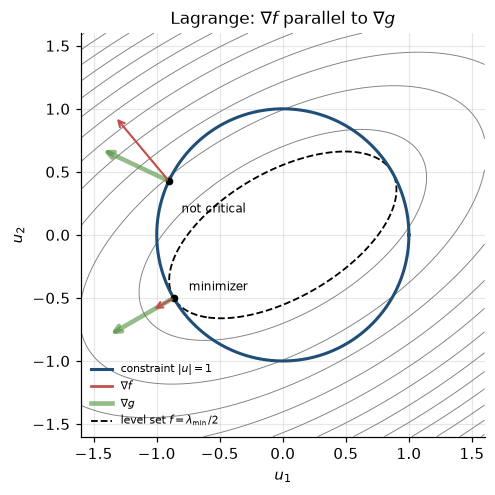

In [2]:
# Lagrange: minimize f(u) = u^T Q u / 2 on the unit circle (Q from E3 with kappa = 4).
Q_lag, _ = quadratic_E3(4.0)
lam_lag, V_lag = np.linalg.eigh(Q_lag)
u_min = V_lag[:, 0]
print("eigenvalues of Q:", lam_lag, "  min of f on the circle =", 0.5 * lam_lag[0])
print("Lagrange condition at the minimizer: Q u - lambda u =", Q_lag @ u_min - lam_lag[0] * u_min)

fig, ax = plt.subplots(figsize=(5.0, 4.6))
g1, g2 = np.meshgrid(np.linspace(-1.6, 1.6, 200), np.linspace(-1.6, 1.6, 200))
pts = np.stack([g1, g2], axis=-1)
ax.contour(g1, g2, quadratic_value(Q_lag, np.zeros(2), pts), levels=12, colors=COLORS["reference"], linewidths=0.6)
ax.contour(g1, g2, quadratic_value(Q_lag, np.zeros(2), pts), levels=[0.5 * lam_lag[0]], colors="black", linewidths=1.2, linestyles="dashed")
s = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(s), np.sin(s), color=COLORS["state"], lw=2, label=r"constraint $|u|=1$")
for u, name, offset in [(u_min, "minimizer", (0.12, 0.06)), (np.array([np.cos(2.7), np.sin(2.7)]), "not critical", (0.1, -0.25))]:
    grad_f = Q_lag @ u
    ax.annotate("", xy=u + 0.6 * u, xytext=u, arrowprops=dict(arrowstyle="->", color=COLORS["adjoint"], lw=3, alpha=0.6))
    ax.annotate("", xy=u + 0.2 * grad_f, xytext=u, arrowprops=dict(arrowstyle="->", color=COLORS["control"], lw=1.4))
    ax.plot(*u, "o", color="black", ms=4); ax.text(*(u + np.array(offset)), name, fontsize=8)
ax.plot([], [], color=COLORS["control"], label=r"$\nabla f$"); ax.plot([], [], color=COLORS["adjoint"], lw=3, alpha=0.6, label=r"$\nabla g$")
ax.plot([], [], color="black", ls="--", lw=1.2, label=r"level set $f=\lambda_{\min}/2$")
ax.set_aspect("equal"); ax.set_xlabel("$u_1$"); ax.set_ylabel("$u_2$"); ax.legend(fontsize=7, loc="lower left")
ax.set_title("Lagrange: $\\nabla f$ parallel to $\\nabla g$")
plt.tight_layout(); plt.show()

**Figure 1.** First-order conditions with a constraint: level sets of $f(u)=\tfrac12u^\top Qu$ (E3 with $\kappa=4$) and the constraint $|u|=1$. At the minimizer, an eigenvector of $\lambda_{\min}$, the gradients $\nabla f$ (thin arrow) and $\nabla g$ (thick arrow) are parallel, and the level set $f=\lambda_{\min}/2$ (dashed) touches the circle there. At a non-critical point $\nabla f$ has a component along the circle.

*Interpretation.* Moving along the circle against the tangential component of $\nabla f$ decreases $f$, so a point where that component is nonzero cannot be a minimizer. This is the geometric content of $\nabla f=\lambda\nabla g$. The printed eigenvalues confirm that the minimum of $f$ on the circle is $\tfrac12\lambda_{\min}$.

## 3. Existence of minimizers
`CORE`

> **Theorem 1 (existence in finite dimension; the finite-dimensional case of the direct method, pp. 187–188).**
> *Assumptions:* $J:\mathbb R^n\to\mathbb R$ is continuous and coercive ($J(u)\to+\infty$ as $|u|\to\infty$).
> *Conclusion:* $J$ attains its minimum. If $J$ is moreover strictly convex, the minimizer is unique.
> *Interpretation:* coercivity keeps minimizing sequences bounded, and compactness of bounded sets in $\mathbb R^n$ does the rest.

*Proof.* Let $I=\inf J$ and $J(u_n)\searrow I$. By coercivity the sequence $(u_n)$ is bounded, and in particular $I>-\infty$. By the Bolzano–Weierstrass theorem a subsequence converges, $u_n\to u^*$, and by continuity $J(u^*)=\lim J(u_n)=I$. If $J$ is strictly convex, two minimizers $u\ne v$ would give $J(\tfrac{u+v}2)<\tfrac12J(u)+\tfrac12J(v)=I$, which is impossible. $\square$

Convexity is not needed for existence in finite dimension. It matters for uniqueness, and, in infinite dimension, for existence itself: when the unknown is a function, for instance a control $u\in L^2(0,T)$, bounded sequences need not have convergent subsequences. The **direct method of the calculus of variations** (pp. 187–188) then replaces compactness by *weak* compactness and continuity by *convexity*: a continuous, convex, coercive functional on a Hilbert space has a minimizer. Its four-step proof is in the DEEPER LOOK §11.

**This is the argument that gave the controls of Part I.** In notebook 03, coercivity of the HUM functional came from observability, and strict convexity from the same inequality; in notebook 04, $J_{bb}$ and $J_{sw}$ followed the same pattern. Each hypothesis can fail:

- without coercivity, $J(u)=e^u$ on $\mathbb R$ has infimum $0$, never attained (Exercise 1);
- without a Hilbert (reflexive) space, weak compactness fails. Minimizing the length $\int_0^1|x'(t)|\,dt$ of curves from $A$ to $B$ leads out of the Hilbert setting (p. 21; DEEPER LOOK §11 and Exercise 6).

## 4. The gradient flow and its Lyapunov function
`CORE`

To *compute* a minimizer, we let $u$ move in the direction of steepest descent. The **gradient flow** of $J$ is the ODE, in the fictitious time $\tau\ge0$,
$$
u'(\tau)=-\nabla J(u(\tau)),\qquad u(0)=u_0
$$
(pp. 183–184). Throughout, $J\in C^1(\mathbb R^n)$ with a locally Lipschitz gradient, so that the flow is well defined.

> **Theorem 2 (Lyapunov identity; p. 184).**
> *Conclusion:* along every trajectory of the gradient flow,
> $$\frac{d}{d\tau}J(u(\tau))=-|\nabla J(u(\tau))|^2\le0 .$$
> *Interpretation:* **$J$ is a Lyapunov function of its own gradient flow**: its value decreases along trajectories, strictly away from critical points.

*Proof.* Multiply the equation by $\nabla J(u(\tau))$: $\frac{d}{d\tau}J(u)=\langle\nabla J(u),u'\rangle=-|\nabla J(u)|^2$. $\square$

Compare with notebook 05, where $\frac{d}{dt}|x|^2=-2|B^*x|^2$: there the energy was the Lyapunov function, and the dissipation was the observation. Here the dissipation is the squared gradient.

**Consequences (pp. 184–185).**

1. If $J$ is bounded below, $J(u(\tau))$ decreases to a limit $I$, and integrating the identity gives $\int_0^\infty|\nabla J(u(\tau))|^2d\tau\le J(u_0)-I<\infty$.
2. If $J$ is coercive, the trajectory stays in the sublevel set $\{J\le J(u_0)\}$, which is bounded. In finite dimension it is therefore precompact.
3. **Critical points.** In finite dimension every accumulation point of the trajectory is a critical point (LaSalle's invariance principle; no convexity needed).
4. **The minimizer.** If $J$ is convex with a unique minimizer $u^*$, the trajectory converges to $u^*$, without a rate. Proofs of 3–4 and the infinite-dimensional case: DEEPER LOOK §12.

5. **Exponential convergence under strong convexity** *(pedagogical addition, developing the remark on p. 186 that distances diminish along trajectories when $J$ is convex)*. Suppose
$$
\langle\nabla J(u)-\nabla J(v),u-v\rangle\ge\alpha|u-v|^2\qquad\text{for all }u,v,\quad\alpha>0 .
\tag{SC}
$$
If $u(\tau)$ and $v(\tau)$ are two trajectories, then $\frac{d}{d\tau}\tfrac12|u-v|^2=-\langle\nabla J(u)-\nabla J(v),u-v\rangle\le-\alpha|u-v|^2$, so
$$
|u(\tau)-v(\tau)|\le e^{-\alpha\tau}|u(0)-v(0)| .
$$
Taking $v\equiv u^*$, the constant trajectory at the minimizer, gives $|u(\tau)-u^*|\le e^{-\alpha\tau}|u_0-u^*|$.

## 5. Euler discretization: gradient descent
`CORE`

The gradient flow is an ODE. Its **explicit Euler** discretization with time step $\eta$ is
$$
u_{k+1}=u_k-\eta\,\nabla J(u_k),\qquad k=0,1,2,\dots
$$
This is the **gradient method** (steepest descent) of p. 153. The step size $\eta$ is the time step: after $k$ steps the iterate approximates $u(\tau)$ at $\tau=k\eta$.

> **Theorem 3 (convergence of gradient descent; p. 183).**
> *Assumptions:* $\nabla J$ satisfies (SC) with $\alpha>0$, and it is Lipschitz: $|\nabla J(u)-\nabla J(v)|^2\le M|u-v|^2$, with $M=L^2$.
> *Conclusion:* with $u^*$ the minimizer,
> $$|u_k-u^*|\le\big(1-2\eta\alpha+\eta^2M\big)^{k/2}|u_0-u^*| ,$$
> and the iterates converge linearly whenever $0<\eta<2\alpha/M$, a *sufficient*, not optimal, range. The best factor in this bound is obtained at $\eta=\alpha/M$, where it equals $\sqrt{1-\alpha^2/M}$.
> *Interpretation:* gradient descent inherits the contraction of the gradient flow, *provided the time step is small compared with the fastest scale of the problem*.

*Proof.* Since $\nabla J(u^*)=0$, the error $e_k=u_k-u^*$ satisfies $e_{k+1}=e_k-\eta\big(\nabla J(u_k)-\nabla J(u^*)\big)$. Expanding the square and using both assumptions,
$$
|e_{k+1}|^2=|e_k|^2-2\eta\langle\nabla J(u_k)-\nabla J(u^*),e_k\rangle+\eta^2|\nabla J(u_k)-\nabla J(u^*)|^2\le(1-2\eta\alpha+\eta^2M)\,|e_k|^2 .
$$
The factor is smaller than $1$ exactly when $\eta(\eta M-2\alpha)<0$, that is, when $0<\eta<2\alpha/M$. Minimizing it over $\eta$ gives $\eta=\alpha/M$. $\square$

> **Remark on the source slides.** P. 183 concludes "convergence is guaranteed for $0<\rho<1$ small enough", and indexes the bound from $u_1$. The precise range given by the estimate is $0<\rho<2\alpha/M$, which can be much smaller than $1$ when $M$ is large.

**Quadratics: the sharp picture** *(pedagogical addition)*. For the example E3,
$$
J(u)=\tfrac12u^\top Qu-q^\top u,\qquad\nabla J(u)=Qu-q,\qquad u^*=Q^{-1}q,
$$
with $Q$ symmetric positive definite and eigenvalues $\lambda_{\min}=\lambda_1\le\dots\le\lambda_n=\lambda_{\max}$, the error obeys exactly
$$
e_{k+1}=(I-\eta Q)\,e_k .
$$
Along the eigenvector $v_j$ of $Q$ it is multiplied by $1-\eta\lambda_j$ at every step. Hence

- GD converges from every $u_0$ **if and only if** $|1-\eta\lambda_j|<1$ for all $j$, that is, $0<\eta<2/\lambda_{\max}$. If $\eta>2/\lambda_{\max}$, the component along $v_n$ is amplified by $|1-\eta\lambda_{\max}|>1$ at each step, and the iterates blow up;
- the factor $\max_j|1-\eta\lambda_j|$ is smallest at $\eta=2/(\lambda_{\min}+\lambda_{\max})$, where it equals $\dfrac{\kappa-1}{\kappa+1}$, with $\kappa=\lambda_{\max}/\lambda_{\min}$;
- reducing the error by a factor $\delta$ therefore takes about $\dfrac{\ln(1/\delta)}{\ln\frac{\kappa+1}{\kappa-1}}\approx\dfrac\kappa2\ln(1/\delta)$ steps when $\kappa$ is large.

The flow itself contracts the component along $v_j$ by $e^{-\lambda_j\tau}$, so its slowest time scale is $1/\lambda_{\min}$. The Euler scheme is stable only if $\eta<2/\lambda_{\max}$, the fastest time scale. **An ill-conditioned problem is a stiff ODE**: the number of steps is governed by the ratio of the two scales, the condition number $\kappa$. The convergence of the optimization method and the stability of the time discretization are one and the same condition.

For E3, $\alpha=\lambda_{\min}$ and $L=\lambda_{\max}$, so Theorem 3 guarantees convergence only for $\eta<2\lambda_{\min}/\lambda_{\max}^2$, smaller than the sharp threshold $2/\lambda_{\max}$ by the factor $\kappa$. The theorem only uses (SC) and the Lipschitz bound, and it holds for maps that are not gradients, for which it is sharp (Exercise 4). For gradients of convex functions, the range $0<\eta<2/L$ is known to suffice; we state this without proof.

## 6. Laboratory: conditioning on the quadratic landscape E3
`CORE`

We use E3 in $\mathbb R^2$ with $Q=R\,\mathrm{diag}(1,\kappa)R^\top$, a rotation $R$ by $30^\circ$, so that $\lambda_{\min}=1$ and $\lambda_{\max}=\kappa$, and minimizer $u^*=(1,0.5)$. Starting from $u_0=(-1.5,1.5)$, we compare the exact gradient flow with gradient descent at the best step $\eta=2/(\lambda_{\min}+\lambda_{\max})$, for $\kappa=1,10,100$.

> **Predict.** (a) For $\kappa=1$, how many GD steps does the best step size need? (b) Going from $\kappa=10$ to $\kappa=100$, by what factor does the number of steps needed to gain six digits grow? (c) What happens for $\kappa=10$ if $\eta$ is $1\%$ larger than $2/\lambda_{\max}$?

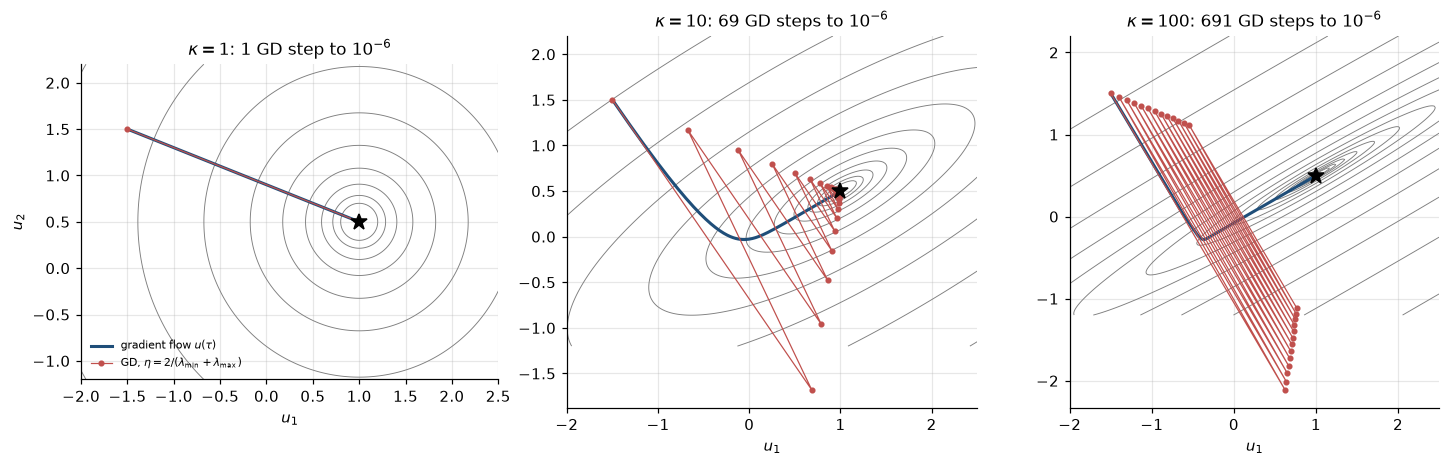

steps to reduce the error by 1e-6 at the best step: {1.0: 1, 10.0: 69, 100.0: 691}
prediction ln(1e6)/ln((kappa+1)/(kappa-1)): {10.0: 68.8, 100.0: 690.8}


In [3]:
kappas = [1.0, 10.0, 100.0]
u0 = np.array([-1.5, 1.5])
steps_to_1e6 = {}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
g1, g2 = np.meshgrid(np.linspace(-2.0, 2.5, 220), np.linspace(-1.2, 2.2, 220))
for ax, kappa in zip(axes, kappas):
    Q, q = quadratic_E3(kappa)
    lam_min, lam_max = np.linalg.eigvalsh(Q)
    u_star = np.linalg.solve(Q, q)
    eta = 2 / (lam_min + lam_max)
    flow = quadratic_flow(Q, q, u0, np.linspace(0, 10, 600))
    gd = gradient_descent(lambda u: Q @ u - q, u0, eta, 2000)
    errors = np.linalg.norm(gd - u_star, axis=1) / np.linalg.norm(u0 - u_star)
    steps_to_1e6[kappa] = int(np.argmax(errors <= 1e-6))
    ax.contour(g1, g2, quadratic_value(Q, q, np.stack([g1, g2], axis=-1)), levels=np.geomspace(0.02, 200, 14) + quadratic_value(Q, q, u_star),
               colors=COLORS["reference"], linewidths=0.6, linestyles="solid")
    ax.plot(*flow.T, color=COLORS["state"], lw=2, label=r"gradient flow $u(\tau)$")
    ax.plot(*gd[:26].T, "o-", color=COLORS["control"], ms=3, lw=0.8, label=r"GD, $\eta=2/(\lambda_{\min}+\lambda_{\max})$")
    ax.plot(*u_star, "*", color="black", ms=11)
    n_steps = steps_to_1e6[kappa]
    ax.set_title(rf"$\kappa={kappa:g}$: {n_steps} GD step{'s' if n_steps > 1 else ''} to $10^{{-6}}$")
    ax.set_aspect("equal"); ax.set_xlabel("$u_1$")
axes[0].set_ylabel("$u_2$"); axes[0].legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()
print("steps to reduce the error by 1e-6 at the best step:", steps_to_1e6)
print("prediction ln(1e6)/ln((kappa+1)/(kappa-1)):", {k: round(float(np.log(1e6) / np.log((k + 1) / (k - 1))), 1) for k in kappas[1:]})

**Figure 2.** E3 for $\kappa=1,10,100$: level sets of $J$, the exact gradient flow from $u_0=(-1.5,1.5)$ (solid), the first 25 iterates of gradient descent with the best step $\eta=2/(\lambda_{\min}+\lambda_{\max})$ (dots), and the minimizer (star). Each title gives the number of GD steps needed to reduce the error by $10^{-6}$.

*Interpretation (answers (a) and (b)).* For $\kappa=1$ the level sets are circles, $-\nabla J$ points at the minimizer, and **one step** with $\eta=1$ lands on it. As $\kappa$ grows, the level sets become long narrow valleys. The flow first falls quickly into the valley, along the fast direction, and then crawls along it. Gradient descent at the best step overshoots across the valley and zigzags, because the fast component is multiplied by $1-\eta\lambda_{\max}\approx-1$. Going from $\kappa=10$ to $\kappa=100$ multiplies the number of steps by about $10$, as the estimate $\tfrac\kappa2\ln(10^6)$ predicts. The printed counts agree with the prediction of §5.

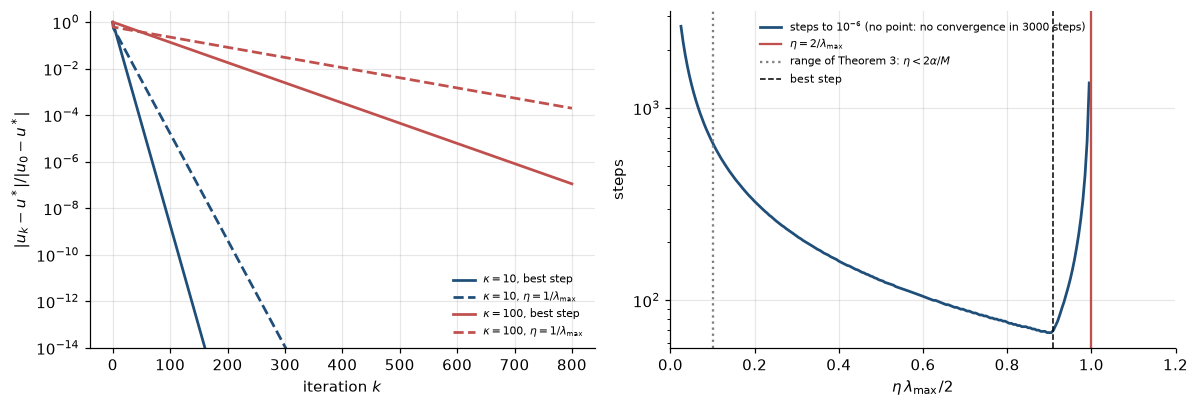

kappa = 10, eta = 0.99 x 2/lambda_max: error after 300 steps = 4.936e-03
kappa = 10, eta = 1.01 x 2/lambda_max: error after 300 steps = 8.046e+02


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for kappa, color in zip(kappas[1:], (COLORS["state"], COLORS["control"])):
    Q, q = quadratic_E3(kappa)
    u_star = np.linalg.solve(Q, q)
    for eta, style, name in [(2 / (1 + kappa), "-", "best step"), (1 / kappa, "--", r"$\eta=1/\lambda_{\max}$")]:
        gd = gradient_descent(lambda u: Q @ u - q, u0, eta, 800)
        ax1.semilogy(np.linalg.norm(gd - u_star, axis=1) / np.linalg.norm(u0 - u_star), style, color=color, label=rf"$\kappa={kappa:g}$, {name}")
ax1.set_xlabel("iteration $k$"); ax1.set_ylabel(r"$|u_k-u^*|/|u_0-u^*|$"); ax1.set_ylim(1e-14, 3); ax1.legend(fontsize=7)

# Stability threshold for kappa = 10: number of steps to 1e-6 as a function of eta * lambda_max / 2.
Q, q = quadratic_E3(10.0)
u_star = np.linalg.solve(Q, q)
lam_max = np.linalg.eigvalsh(Q)[-1]
ratios = np.linspace(0.02, 1.2, 237)
def steps_to_tolerance(eta, n_max=3000, tol=1e-6):
    # Number of GD steps until the relative error is below tol; -1 if not reached in n_max steps.
    with np.errstate(over="ignore", invalid="ignore"):     # divergent steps overflow on purpose
        iterates = gradient_descent(lambda u: Q @ u - q, u0, eta, n_max)
        rel = np.linalg.norm(iterates - u_star, axis=1) / np.linalg.norm(u0 - u_star)
    return int(np.argmax(rel <= tol)) if (rel <= tol).any() else -1


counts = np.array([steps_to_tolerance(2 * r / lam_max) for r in ratios], dtype=float)
ax2.semilogy(ratios, np.where(counts > 0, counts, np.nan), color=COLORS["state"], label="steps to $10^{-6}$ (no point: no convergence in 3000 steps)")
ax2.axvline(1.0, color=COLORS["control"], lw=1.5, label=r"$\eta=2/\lambda_{\max}$")
ax2.axvline(1 / 10, color=COLORS["reference"], ls=":", lw=1.5, label=r"range of Theorem 3: $\eta<2\alpha/M$")
ax2.axvline(10 / 11, color="black", ls="--", lw=1, label="best step")
ax2.set_xlim(0, 1.2); ax2.set_xlabel(r"$\eta\,\lambda_{\max}/2$"); ax2.set_ylabel("steps"); ax2.legend(fontsize=7, loc="upper center")
plt.tight_layout(); plt.show()

for r in (0.99, 1.01):
    gd = gradient_descent(lambda u: Q @ u - q, u0, 2 * r / lam_max, 300)
    print(f"kappa = 10, eta = {r:.2f} x 2/lambda_max: error after 300 steps = {np.linalg.norm(gd[-1] - u_star):.3e}")

**Figure 3.** *Left:* relative error of gradient descent on E3 for $\kappa=10$ and $\kappa=100$, with the best step (solid) and with $\eta=1/\lambda_{\max}$ (dashed). *Right:* for $\kappa=10$, the number of steps needed to reduce the error by $10^{-6}$ as a function of the step size, measured in units of the stability threshold $2/\lambda_{\max}$. Vertical lines: the threshold (solid), the best step (dashed), and the range guaranteed by Theorem 3 (dotted).

*Interpretation (answer to (c)).* All curves are straight lines on the logarithmic scale: the convergence is linear, with the factor predicted in §5. The step $1/\lambda_{\max}$ is safe but about twice as slow as the best step. The number of steps falls as $\eta$ grows, until just below the threshold. There the fast component starts to oscillate with little damping, and at $2/\lambda_{\max}$ the method stops converging: with $\eta$ only $1\%$ above the threshold, the printed error after 300 steps has grown to about $8\cdot10^2$, while $1\%$ below it the error has decreased to about $5\cdot10^{-3}$. The range of Theorem 3 is a factor $\kappa$ more cautious than necessary for this quadratic.

## 7. Back to control: the HUM functional
`CORE`

**HUM converts controllability into the minimization of a coercive functional.** In notebook 03, observability made the dual functional coercive, the existence result of §3 gave a minimizer, and the control was read off it. This section adds the computational side.

Notebook 03 already ran gradient descent on the HUM functional, $\nabla J(\varphi_T)=\mathcal G_T\varphi_T-d$, with $\eta=1/\lambda_{\max}$, and found a number of steps growing like $\kappa(\mathcal G_T)$ (notebook 03, §10 and Figure 5). We do not repeat that experiment. The theory of §5 now explains it: **the HUM functional is an E3 quadratic with $Q=\mathcal G_T$.** In the language of Theorem 3,
$$
\alpha=\lambda_{\min}(\mathcal G_T)=c_{\rm term},\qquad L=\lambda_{\max}(\mathcal G_T),\qquad\kappa=\kappa(\mathcal G_T).
$$
The strong-convexity constant of the dual problem is the **observability constant**. A weakly observable system is a badly conditioned optimization problem. The cell below only evaluates these constants for the systems of notebook 03, with $T=5$.

In [5]:
A1, B1 = harmonic_oscillator()
systems = {"E1": (A1, B1)}
for eps in (1.0, 0.1, 0.01):
    systems[f"E2, eps = {eps}"] = near_uncontrollable_system(eps)
print(f"{'system':14s} {'alpha = c_term':>15s} {'L = lam_max':>12s} {'kappa':>11s} {'best-step factor':>17s} {'steps to 1e-6 (est.)':>21s}")
for name, (A_s, B_s) in systems.items():
    lam = np.linalg.eigvalsh(gramian(A_s, B_s, 5.0))
    kappa_G = lam[-1] / lam[0]
    factor = (kappa_G - 1) / (kappa_G + 1)
    print(f"{name:14s} {lam[0]:15.3e} {lam[-1]:12.3f} {kappa_G:11.3e} {factor:17.8f} {np.log(1e6) / -np.log(factor):21.0f}")

system          alpha = c_term  L = lam_max       kappa  best-step factor  steps to 1e-6 (est.)
E1                   2.021e+00        2.979   1.475e+00        0.19178485                     8
E2, eps = 1.0        3.113e-01        3.164   1.016e+01        0.82081252                    70
E2, eps = 0.1        3.311e-03        2.981   9.003e+02        0.99778102                  6219
E2, eps = 0.01       3.313e-05        2.979   8.993e+04        0.99997776                621222


For E1 a handful of steps suffices. For E2 the condition number grows like $\varepsilon^{-2}$ (notebook 03), so the estimated number of steps for $\varepsilon=0.01$ is in the hundreds of thousands, even at the best step. The control problem has not become harder in the yes/no sense: the system is controllable for every $\varepsilon>0$. What has become harder is the *computation*. The same mechanism, ill-conditioning inherited from weak observability, is much stronger for discretized PDEs, the subject of [notebook 07](07_adjoints_density_heat_control.ipynb).

## 8. Control ↔ ML
`CORE`

- **Training is gradient descent.** **DIRECT CONNECTION.** Training a learning machine means minimizing a loss $J(w)$ over the parameters $w$ by the same update $w_{k+1}=w_k-\eta\nabla J(w_k)$. The step size is called the *learning rate*, and the stability threshold of §5 becomes the familiar observation that too large a learning rate makes training diverge ([notebook 10](10_training_gd_sgd.ipynb)). What changes is the loss: it is built from data, and it is rarely quadratic or convex.
- **Conditioning.** **FORWARD CONNECTION.** Narrow valleys, zigzags and the factor $\kappa$ motivate momentum methods, the heavy ball of notebook 05, §6 ([notebook 11](11_optimization_algorithms_ml.ipynb)).
- **Multipliers and adjoints.** **FORWARD CONNECTION.** Lagrange multipliers became adjoint states in notebook 03. Computing gradients through a dynamical constraint with an adjoint is [notebook 07](07_adjoints_density_heat_control.ipynb), where the link with backpropagation becomes a direct one ([notebook 13](13_resnets_neural_odes.ipynb)).
- **Transport and linear programming** (DEEPER LOOK §10). **FORWARD CONNECTION.** They return in neural transport ([notebook 16](16_neural_transport.ipynb)) and in sparse shallow networks ([notebook 12](12_shallow_networks_representation_sparsity.ipynb)).

## 9. Fermat's principle and Snell's law
`DEEPER LOOK`

**Fermat's principle** states that light follows the path of shortest *optical length*, that is, of least travel time, between two points (p. 148). Light travels from a point at height $a$ above a flat interface, in a medium where its speed is $v_1$, to a point at depth $b$ below it, where its speed is $v_2$, at horizontal distance $\ell$. If it crosses the interface at horizontal position $x$, the travel time is (p. 149)
$$
T(x)=\frac{\sqrt{a^2+x^2}}{v_1}+\frac{\sqrt{b^2+(\ell-x)^2}}{v_2}.
$$
Fermat found the problem too difficult for an analytical treatment; the computation was carried out by Leibniz in 1684 (p. 149). Today it takes two lines (p. 150):
$$
T'(x)=\frac1{v_1}\frac{x}{\sqrt{a^2+x^2}}-\frac1{v_2}\frac{\ell-x}{\sqrt{b^2+(\ell-x)^2}} .
$$
With $\sin\theta_1=x/\sqrt{a^2+x^2}$ and $\sin\theta_2=(\ell-x)/\sqrt{b^2+(\ell-x)^2}$, the angles to the normal, $T'(x)=0$ is **Snell's law**:
$$
\frac{\sin\theta_1}{\sin\theta_2}=\frac{v_1}{v_2}.
$$
Moreover
$$
T''(x)=\frac1{v_1}\frac{a^2}{(a^2+x^2)^{3/2}}+\frac1{v_2}\frac{b^2}{(b^2+(\ell-x)^2)^{3/2}}>0,
$$
so $T$ is strictly convex, and the critical point is the unique minimizer (p. 150). This is the pattern of §§2–3 in miniature: a first-order condition identifies the candidate, and convexity certifies it.

> **Predict.** Take $a=b=1$, $\ell=2$ and light twice as slow below the interface, $v_2=v_1/2$. The straight segment crosses the interface at $x=1$. Does the light cross to the left or to the right of $x=1$?

crossing point x = 1.538264;  sin(theta1)/sin(theta2) = 2.000000;  v1/v2 = 2.000000


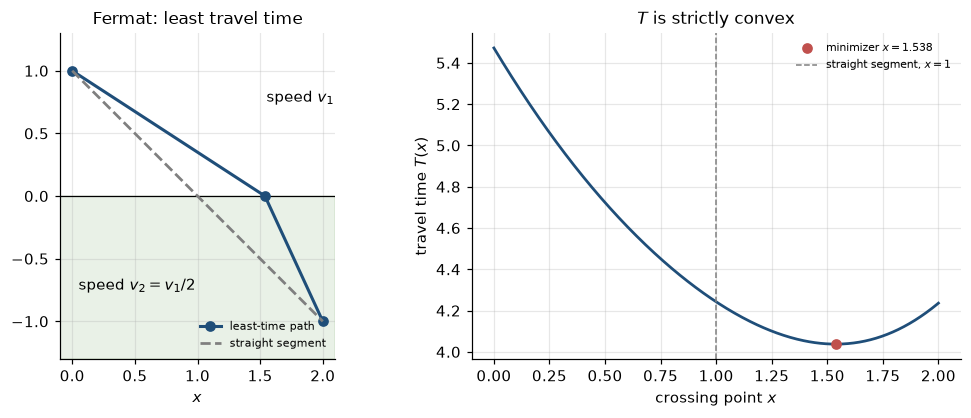

In [6]:
# Snell: minimize the travel time T(x) on [0, ell].
a, b, ell, v1, v2 = 1.0, 1.0, 2.0, 1.0, 0.5
travel_time = lambda x: np.sqrt(a**2 + x**2) / v1 + np.sqrt(b**2 + (ell - x) ** 2) / v2
x_snell = minimize_scalar(travel_time, bounds=(0, ell), method="bounded", options={"xatol": 1e-12}).x
sin1, sin2 = x_snell / np.hypot(a, x_snell), (ell - x_snell) / np.hypot(b, ell - x_snell)
print(f"crossing point x = {x_snell:.6f};  sin(theta1)/sin(theta2) = {sin1 / sin2:.6f};  v1/v2 = {v1 / v2:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.9))
axes[0].axhspan(-1.3, 0, color=COLORS["adjoint"], alpha=0.12)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].plot([0, x_snell, ell], [a, 0, -b], "-o", color=COLORS["state"], lw=2, label="least-time path")
axes[0].plot([0, ell], [a, -b], "--", color=COLORS["reference"], label="straight segment")
axes[0].text(1.55, 0.75, "speed $v_1$", fontsize=10); axes[0].text(0.05, -0.75, "speed $v_2=v_1/2$", fontsize=10)
axes[0].set_xlim(-0.1, 2.1); axes[0].set_ylim(-1.3, 1.3); axes[0].set_aspect("equal"); axes[0].legend(fontsize=7, loc="lower right")
axes[0].set_xlabel("$x$"); axes[0].set_title("Fermat: least travel time")

xs = np.linspace(0, ell, 400)
axes[1].plot(xs, travel_time(xs), color=COLORS["state"])
axes[1].plot(x_snell, travel_time(x_snell), "o", color=COLORS["control"], label=f"minimizer $x={x_snell:.3f}$")
axes[1].axvline(1.0, color=COLORS["reference"], ls="--", lw=1, label="straight segment, $x=1$")
axes[1].set_xlabel("crossing point $x$"); axes[1].set_ylabel("travel time $T(x)$"); axes[1].legend(fontsize=7)
axes[1].set_title("$T$ is strictly convex")
plt.tight_layout(); plt.show()

**Figure 4.** Fermat's principle. *Left:* the least-time path of light from $(0,1)$ to $(2,-1)$ when the lower medium is twice as slow, and the straight segment. *Right:* the travel time $T(x)$ and its minimizer.

*Interpretation (answer to the prediction).* The light crosses to the **right** of $x=1$, at $x\approx1.538$. It shortens its path in the slow medium at the price of a longer path in the fast one, and the printed ratio $\sin\theta_1/\sin\theta_2$ equals $v_1/v_2=2$, as Snell's law requires. The shortest path is not the fastest one.

## 10. Inequality constraints: linear programming and transport
`DEEPER LOOK`

In many problems the constraints are inequalities, and the minimizer lies on the boundary of the admissible set, where $\nabla J$ need not vanish. The classic example is **linear programming** (pp. 172–173). A company stores $s_i$ items in each of $M$ storage locations, $N$ clients request $r_j$ items each, and transporting one item from location $i$ to client $j$ costs $c_{ij}$. The unknowns are the amounts $v_{ij}$ delivered from $i$ to $j$, and the problem is
$$
\min_{\{v_{ij}\}}\ \sum_{i=1}^M\sum_{j=1}^Nc_{ij}v_{ij}
\quad\text{subject to}\quad v_{ij}\ge0,\qquad\sum_{j=1}^Nv_{ij}\le s_i,\qquad\sum_{i=1}^Mv_{ij}=r_j .
$$
The cost is linear and the admissible set is a polytope. A minimizer, when it exists, can always be found at a vertex. Such problems are solved by dedicated algorithms (simplex and interior-point methods), not by following the gradient, which is constant. Software for them is widely available (p. 174 mentions IPOPT).

**Discrete optimal transport** *(the slides introduce Monge's problem on p. 151; the discrete formulation below is a pedagogical addition)*. Take $M=N$ points $X_i$ (piles of sand, *déblais*) and $Y_j$ (holes, *remblais*), each carrying mass $1/N$, and the cost $c_{ij}=|X_i-Y_j|^2$. The transportation LP with $s_i=r_j=1/N$ and equality in all constraints asks for the cheapest way to move the first distribution onto the second. We use the example E8: an empirical sample of a Gaussian $\rho_0$ and one of the uniform distribution $\rho_T$ on $[0,1]^2$.

LP status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
optimal transport cost = 0.065750;  plan entries take the values [0. 1.] (times 1/N)


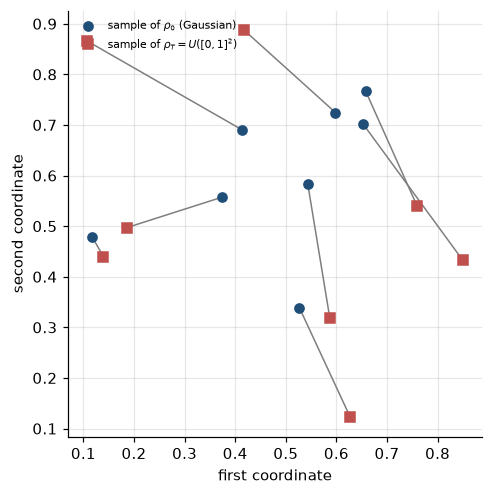

In [7]:
rng = np.random.default_rng(6)
X0, X1 = samples_E8(rng, n=8)                       # E8: Gaussian sample -> uniform sample, N = 8 each
N = len(X0)
cost = ((X0[:, None, :] - X1[None, :, :]) ** 2).sum(axis=-1)

A_eq = np.zeros((2 * N, N * N))                    # row sums (sources) and column sums (targets)
for i in range(N):
    A_eq[i, i * N:(i + 1) * N] = 1.0
    A_eq[N + i, i::N] = 1.0
def transport_lp(cost):
    # min sum c_ij v_ij  subject to  v_ij >= 0, row sums = column sums = 1/N
    result = linprog(cost.ravel(), A_eq=A_eq, b_eq=np.full(2 * N, 1.0 / N), bounds=(0, None), method="highs")
    return result.x.reshape(N, N), result.fun, result.message


plan, ot_cost, lp_message = transport_lp(cost)
print("LP status:", lp_message)
print(f"optimal transport cost = {ot_cost:.6f};  plan entries take the values {np.unique(np.round(N * plan, 9))} (times 1/N)")

fig, ax = plt.subplots(figsize=(5.2, 4.6))
for i, j in zip(*np.nonzero(plan > 1e-9)):
    ax.plot([X0[i, 0], X1[j, 0]], [X0[i, 1], X1[j, 1]], color=COLORS["reference"], lw=1)
ax.plot(*X0.T, "o", color=COLORS["state"], label=r"sample of $\rho_0$ (Gaussian)")
ax.plot(*X1.T, "s", color=COLORS["control"], label=r"sample of $\rho_T=U([0,1]^2)$")
ax.set_aspect("equal"); ax.set_xlabel("first coordinate"); ax.set_ylabel("second coordinate"); ax.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

**Figure 5.** Discrete optimal transport between the two samples of E8, $N=8$ points each, with quadratic cost. The grey segments show the optimal plan computed by the transportation LP.

*Interpretation.* The solver returned a vertex of the admissible polytope, and here it is a **permutation**: each Gaussian point is sent, whole, to one uniform point. (By the Birkhoff–von Neumann theorem, the vertices of this polytope are exactly the permutation matrices divided by $N$; we state this without proof.) The printed cost is the smallest total of squared displacements over all ways of matching the two samples. The same example returns in [notebook 16](16_neural_transport.ipynb), where a neural ODE transports $\rho_0$ to $\rho_T$, and LP returns in [notebook 12](12_shallow_networks_representation_sparsity.ipynb) for sparse shallow networks.

## 11. Existence in a Hilbert space: the direct method
`DEEPER LOOK`

> **Theorem 1′ (direct method of the calculus of variations; pp. 187–188).**
> *Assumptions:* $H$ is a Hilbert space, and $J:H\to\mathbb R$ is continuous, convex and coercive ($J(u)\to+\infty$ as $\|u\|\to\infty$).
> *Conclusion:* $J$ attains its minimum: there is $u^*\in H$ with $J(u^*)=\min_{u\in H}J(u)$.
> *Interpretation:* existence follows from four steps, each of which uses one hypothesis.

*Proof (pp. 187–188).*

**Step 1.** Define $I=\inf_{u\in H}J(u)$. By coercivity, $I>-\infty$: outside a large ball $J$ is larger than $J(0)$, and inside it a continuous convex function is bounded below, because it lies above a continuous affine function.

**Step 2.** Take a **minimizing sequence** $(u_n)$ with $J(u_n)\searrow I$. By coercivity, $(u_n)$ is bounded in $H$.

**Step 3.** $H$ being a Hilbert space, a bounded sequence has a **weakly convergent** subsequence, $u_n\rightharpoonup u^*$ in $H$.

**Step 4.** $J$ being continuous and convex, it is **lower semicontinuous** for the weak topology. Therefore
$$
J(u^*)\le\liminf_{n\to\infty}J(u_n)=I,
$$
and by the definition of the infimum $J(u^*)=I$. $\square$

**Weak lower semicontinuity (Step 4).** In a Hilbert space a continuous function need not be weakly lower semicontinuous. For example, $J(u)=\big|\|u\|^2-1\big|$ on $\ell^2$ is continuous, but the unit vectors $e_n$ satisfy $e_n\rightharpoonup0$ with $J(e_n)=0<J(0)=1$. Convexity repairs this. The sublevel sets $\{J\le t\}$ of a continuous convex function are closed and convex, and closed convex sets are weakly closed (Mazur's lemma, stated here without proof). Hence $u_n\rightharpoonup u$ and $J(u_n)\le t$ imply $J(u)\le t$, which is weak lower semicontinuity. Step 1 also uses convexity: a continuous convex function is bounded below on bounded sets, because it lies above a continuous affine function.

**Where the Hilbert setting is lost (p. 21).** Minimizing the length $\int_0^1|x'(t)|\,dt$ of curves from $A$ to $B$, a problem as old as the Egyptian string stretchers, *"we easily end up working in the BV class of functions of bounded variation, out of the most natural and simple context of Hilbert spaces"*. Minimizing sequences can converge to curves with jumps, and Step 3 fails in $W^{1,1}$ (Exercise 6).

## 12. Long-time behaviour of gradient flows: $\omega$-limit sets and compactness
`DEEPER LOOK`

We continue the consequences of the Lyapunov identity of §4, for $J\in C^1(\mathbb R^n)$ bounded below and coercive (pp. 184–185).

1. Let $\omega(u_0)$, the **$\omega$-limit set**, be the set of accumulation points of $u(\tau)$ as $\tau\to\infty$. It is nonempty, $J=I$ on it, and **every $z\in\omega(u_0)$ is a critical point**, $\nabla J(z)=0$ (Exercise 5). This is LaSalle's invariance principle for gradient systems.
2. If $J$ is convex and has a unique minimizer $u^*$, for instance if $J$ is strictly convex and coercive, then $u^*$ is its only critical point. Hence $\omega(u_0)=\{u^*\}$, and the whole trajectory converges to $u^*$.

> **Remark on the source slides.** On p. 185 the conclusion of the $\omega$-limit argument is written "$J(z)=0$"; it should read $\nabla J(z)=0$. The slide also invokes convexity to deduce that $J(z(t))=I$ along the trajectory issued from $z$. This step does not need convexity: it follows from the invariance of $\omega(u_0)$ under the flow and the continuity of $J$. Convexity is needed only afterwards, to identify the critical point with the minimizer.

**Compactness of trajectories (pp. 184–186).** In infinite dimension a bounded trajectory of the gradient flow need not be precompact, so $\omega(u_0)$ may be empty. The slides indicate the standard remedy. When $J$ is convex, distances between trajectories do not increase (§4, with $\alpha=0$), so it suffices to prove convergence for a dense set of initial data. That set is chosen so that the trajectories are bounded in a smaller space that embeds compactly into the phase space. An example of this situation is the heat equation, which is the gradient flow of the Dirichlet energy $\tfrac12\int|\nabla y|^2$.

## 13. Common misconceptions
`CORE`

**"$\nabla J(u)=0$ means $u$ is a minimizer."** Only for convex $J$. Critical points include maxima and saddles (Exercise 3), and with constraints the condition becomes $\nabla f=\lambda\nabla g$.

**"A function bounded below has a minimizer."** Bounded below alone does not guarantee that the infimum is attained, as $e^u$ shows. Continuity and coercivity are *sufficient* in finite dimension, not necessary; in infinite dimension the direct method uses weak lower semicontinuity and compactness of minimizing sequences (§11).

**"A smaller step is always safer, a larger one always faster."** For a quadratic with symmetric positive definite Hessian, gradient descent converges from every initial point if and only if $\eta<2/\lambda_{\max}$, and below that threshold larger steps are faster up to the best step. Above it, the components along eigenvectors with $\eta\lambda>2$ grow, so every trajectory with a nonzero component there diverges. Very small steps converge, but slowly.

**"Gradient descent is a heuristic."** It is the explicit Euler scheme for the gradient flow, whose convergence follows from a Lyapunov identity under the assumptions of §4 (for instance strong convexity) or, for $\omega$-limit sets, those of §12 ($J\in C^1$, bounded below and coercive). Its own convergence is a stability property of the time discretization.

**"The convergence speed depends on the smallest eigenvalue."** It depends on the ratio $\kappa=\lambda_{\max}/\lambda_{\min}$, because the step size is limited by $\lambda_{\max}$ (§5).

## 14. What you should remember
`CORE`

1. Minimizers satisfy $\nabla J=0$. With a constraint $g=c$ they satisfy $\nabla f=\lambda\nabla g$, and for quadratic forms on the sphere the multipliers are eigenvalues, as in $c_{\rm term}=\lambda_{\min}(\mathcal G_T)$.
2. In finite dimension, continuity and coercivity are sufficient for a minimizer, and strict convexity gives uniqueness. In a Hilbert space the direct method uses weak lower semicontinuity and weak compactness of minimizing sequences; convexity together with continuity is one sufficient way to obtain weak lower semicontinuity (DEEPER LOOK §11).
3. Gradient flow $u'=-\nabla J(u)$: $\frac{d}{d\tau}J=-|\nabla J|^2$, so $J$ is a Lyapunov function. With strong convexity, $|u(\tau)-u^*|\le e^{-\alpha\tau}|u_0-u^*|$.
4. Gradient descent is explicit Euler: $|u_k-u^*|\le(1-2\eta\alpha+\eta^2M)^{k/2}|u_0-u^*|$, and $0<\eta<2\alpha/M$ suffices (a sufficient, not optimal, range).
5. For quadratics with symmetric positive definite Hessian, GD converges from every initial point iff $\eta<2/\lambda_{\max}$, and needs about $\tfrac\kappa2\ln(1/\delta)$ steps at the best step: ill-conditioning is stiffness.
6. HUM turns controllability into the minimization of a coercive quadratic whose strong-convexity constant is the observability constant, so weak observability means slow gradient descent.

## 15. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional and use DEEPER LOOK material. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (when no minimizer exists)** · `FIRST PASS`. Let $J(u)=e^u$ on $\mathbb R$. (a) Which hypothesis of Theorem 1 (§3) fails? (b) Take a minimizing sequence and explain why it cannot converge to a minimizer. (c) Give a continuous coercive function on $\mathbb R$ with two minimizers, and say which hypothesis of the uniqueness statement it violates.

**Exercise 2 ★★ (the bound of p. 183: best step)** · `FIRST PASS`. (a) Minimize $1-2\eta\alpha+\eta^2M$ over $\eta$, and show that with $\kappa=L/\alpha$ the best factor is $\sqrt{1-1/\kappa^2}$. Estimate the number of steps needed to gain a factor $\delta$, and compare with $\tfrac\kappa2\ln(1/\delta)$ for quadratics. (b) For E3 with $\kappa=10$, show that at $\eta=1/\lambda_{\max}$ the bound of Theorem 3 is larger than $1$, although GD converges.

**Exercise 3 ★★ (saddle points)** · `STANDARD`. Let $J(u)=\tfrac14(u_1^2-1)^2+\tfrac12u_2^2$ on $\mathbb R^2$. (a) Find the critical points and classify them. (b) Write the gradient flow and show that the line $\{u_1=0\}$ is invariant. From which initial data does the flow converge to the saddle? (c) Run gradient descent with $\eta=0.1$ from $(0,1)$, from $(10^{-8},1)$ and from $(-10^{-8},1)$ for 400 steps. What do you observe, and what does it say about the claim "GD finds a minimizer"?

**Exercise 4 ★★ (when the bound of p. 183 is sharp)** · `STANDARD`. Let $S=\begin{pmatrix}\alpha&\beta\\-\beta&\alpha\end{pmatrix}$ and $F(u)=Su$. Check that $F$ satisfies both assumptions of Theorem 3 with $M=\alpha^2+\beta^2$, and that the iteration $u_{k+1}=u_k-\eta F(u_k)$ attains the bound with equality. Why does this not contradict Exercise 2(b)?

**Exercise 5 ★★ (LaSalle without convexity)** · `ADVANCED`. Let $J\in C^1(\mathbb R^n)$ have a locally Lipschitz gradient, and be bounded below and coercive. Prove that every point $z$ of the $\omega$-limit set of a gradient-flow trajectory is a critical point of $J$, **without using convexity**. *Hint:* let $u(\tau_n)\to z$, and use the continuity of the flow with respect to the initial data to show that the trajectory $z(s)$ issued from $z$ satisfies $J(z(s))=I$ for $s\in[0,1]$.

**Exercise 6 ★★ (the length functional, p. 21)** · `ADVANCED`. In dimension $d=1$, minimize $J(x)=\int_0^1|x'(t)|\,dt$ over curves with $x(0)=0$ and $x(1)=1$. (a) Show that $\min J=1$, attained by every nondecreasing $C^1$ curve. Which hypothesis of the uniqueness argument fails? (b) Consider $x_n(t)=\min\{1,\max\{0,\,n(t-\tfrac12)+\tfrac12\}\}$. Show that $J(x_n)=1$ for all $n$, and find the pointwise limit of $x_n$. Is it an admissible curve in $W^{1,1}(0,1)$? Which step of the direct method (§11) fails? (c) Why is the Hilbert space $H^1(0,1)$ not a good setting either? *Hint:* compare $J(x_n)$ with $\|x_n\|_{H^1}$.

**Exercise 7 ★★★ (backtracking line search)** · `ADVANCED`. A fixed step needs $\lambda_{\max}$, which is often unknown. The **Armijo backtracking** rule starts each iteration with $\eta=1$ and halves $\eta$ until
$$
J(u_k-\eta\nabla J(u_k))\le J(u_k)-\tfrac12\eta|\nabla J(u_k)|^2 .
$$
Implement it, and apply it to E3 with $\kappa=100$ from $u_0=(-1.5,1.5)$, and to the function of Exercise 3 from $(0.3,1)$. Plot the error against the iteration number for backtracking, for $\eta=1/\lambda_{\max}$ and for the best fixed step, and count the evaluations of $J$ needed by backtracking.

In [8]:
# TODO: student exercise (Exercise 7)
# Write backtracking_gd(J, grad, u0, n_steps) returning the iterates and the cumulative number of
# evaluations of J after each iteration.

def backtracking_gd(J, grad, u0, n_steps):
    ...  # your code here
    return None, 0

## Where are we going?
`CORE`

In this notebook the gradient $\nabla J$ was available in closed form. When $J$ depends on the control through a state equation, as in control problems for PDEs, a gradient by finite differences costs one solve of the state equation per parameter. [Notebook 07](07_adjoints_density_heat_control.ipynb) shows that one extra solve of an **adjoint equation** gives the whole gradient, and uses it, together with the duality of notebook 03, to control the heat equation. [Notebook 08](08_long_time_control_turnpike.ipynb) asks what optimal controls look like over long time horizons.

Notebooks [10](10_training_gd_sgd.ipynb) and [11](11_optimization_algorithms_ml.ipynb) return to the update $u_{k+1}=u_k-\eta\nabla J(u_k)$ with a loss built from data. This gradient descent is exactly the mathematical mechanism that will become training in notebooks 10–11.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Minimization everywhere | 143–153 | Euler's quote; isoperimetry, geodesics, Fermat, transport, minimal surfaces; $\min_UJ$ and the gradient method |
| §2 Lagrange multipliers | 17–18 | $\nabla f=\lambda\nabla g$ and its geometric reason |
| §3 Existence | 187–188, 21 | Direct method (finite-dimensional case in CORE); the length functional |
| §4 Gradient flow | 183–186 | Lyapunov identity; convexity and distances |
| §5 Gradient descent | 153, 183 | $u_{k+1}=u_k-\rho\nabla J(u_k)$ and its convergence rate |
| §9 Fermat and Snell (DEEPER LOOK) | 148–150 | Travel time, $T'=0$, Snell's law, $T''>0$ |
| §10 Linear programming and transport (DEEPER LOOK) | 151, 172–174 | Monge; optimization taxonomy; the logistics LP; software |
| §11 Direct method in a Hilbert space (DEEPER LOOK) | 187–188, 21 | The four steps; BV |
| §12 $\omega$-limit sets and compactness (DEEPER LOOK) | 184–186 | LaSalle; compactness of trajectories |

The source-map rows also record the pedagogical additions (the Rayleigh quotient and Figure 1, the finite-dimensional existence theorem, the strong-convexity rate of the flow, the sharp quadratic analysis, the E3 laboratory and Figures 2–3, the HUM constants, the discrete transport LP and Figure 5) and the corrections (p. 183 step-size range; p. 185 $\nabla J(z)=0$ and the role of convexity).